## Step 1: Import thư viện & đọc dữ liệu thô

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, precision_recall_curve, auc, balanced_accuracy_score
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import joblib

try:
    import caas_jupyter_tools as cjt
    display_tables = True
except Exception:
    display_tables = False

## Step 1.5: EDA và Xử lí outlier

In [2]:
DATA_DIR = Path("data")
DS1_PATH = DATA_DIR / "heart.csv"
DS2_PATH = DATA_DIR / "heart_failure_clinical_records_dataset.csv"
OUT_DIR = DATA_DIR / "output_figs"
MODEL_DIR = DATA_DIR / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df1 = pd.read_csv(DS1_PATH)
df2 = pd.read_csv(DS2_PATH)

print("Dataset1 shape:", df1.shape)
print("Dataset2 shape:", df2.shape)

def show_df(name, df):
    if display_tables:
        cjt.display_dataframe_to_user(name, df.head(10))
    else:
        print(f"Preview {name}:")
        print(df.head(3).to_string(index=False))

show_df("Dataset1_preview", df1)
show_df("Dataset2_preview", df2)

Dataset1 shape: (918, 12)
Dataset2 shape: (299, 13)
Preview Dataset1_preview:
 Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease
  40   M           ATA        140          289          0     Normal    172              N      0.0       Up             0
  49   F           NAP        160          180          0     Normal    156              N      1.0     Flat             1
  37   M           ATA        130          283          0         ST     98              N      0.0       Up             0
Preview Dataset2_preview:
 age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  smoking  time  DEATH_EVENT
75.0        0                       582         0                 20                    1  265000.00               1.9           130    1        0     4            1
55.0        0                      7861         0                 38    

Tổng quan dữ liệu Dataset 1:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


               Age  Sex ChestPainType   RestingBP  Cholesterol   FastingBS  \
count   918.000000  918           918  918.000000   918.000000  918.000000   
unique         NaN    2             4         NaN          NaN         NaN   
top            NaN    M           ASY         NaN          NaN         NaN   
freq           NaN  725           496         NaN          NaN         NaN   
mean     53.510893  NaN           NaN  132.396514   198.799564    0.233115   
std       9.432617  NaN           NaN   18.514154   109.384145    0.423046   
min      28.000000  NaN           NaN    0.000000     0.000000    0.000000   
25%      47.000000  NaN           NaN  120.000000   173.250000    0.000000   
50%      54.000000  NaN           NaN  130.000000   223.000000    0.000000   
75%      60.000000  NaN           NaN  140.000000   267.000000    0.000000   
max      77.000000  NaN           NaN  200.000000   603.000000    1.000000   

       RestingECG       MaxHR ExerciseAngina     Oldpeak ST_Slo

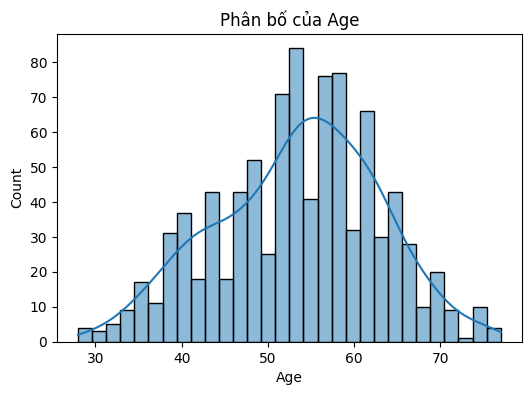

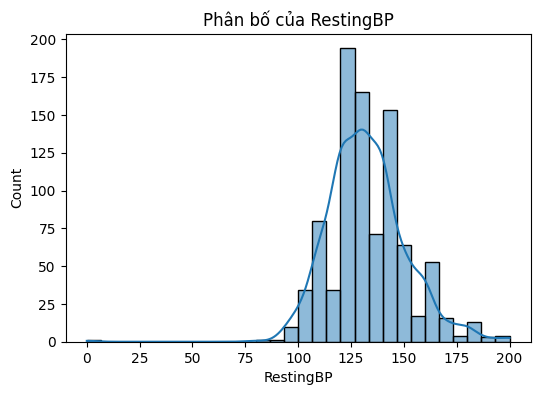

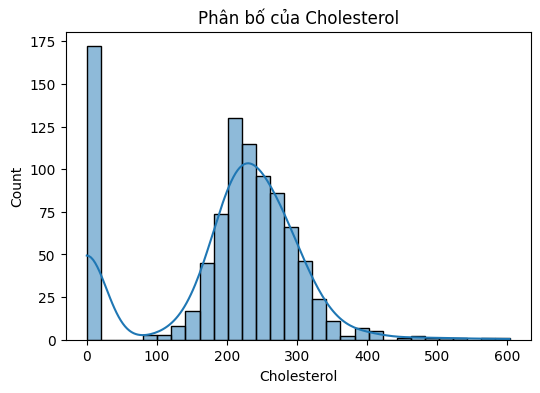

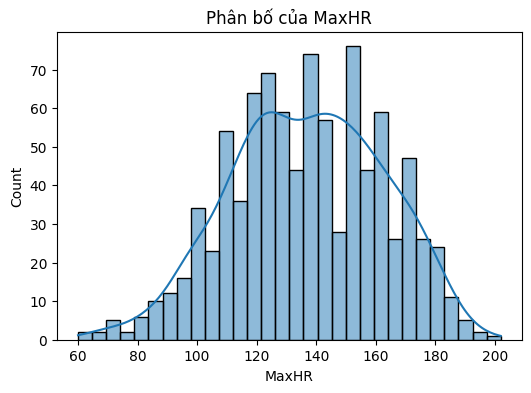

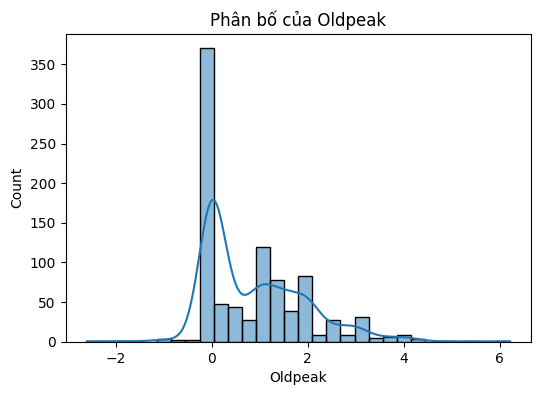

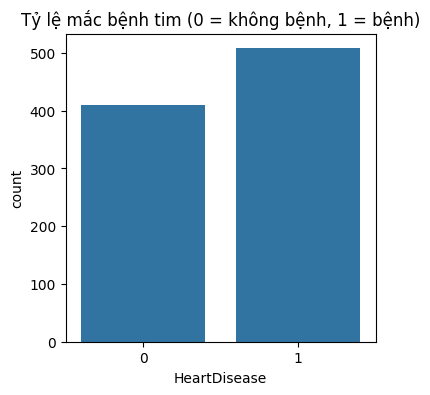

Tỷ lệ mắc bệnh tim:
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


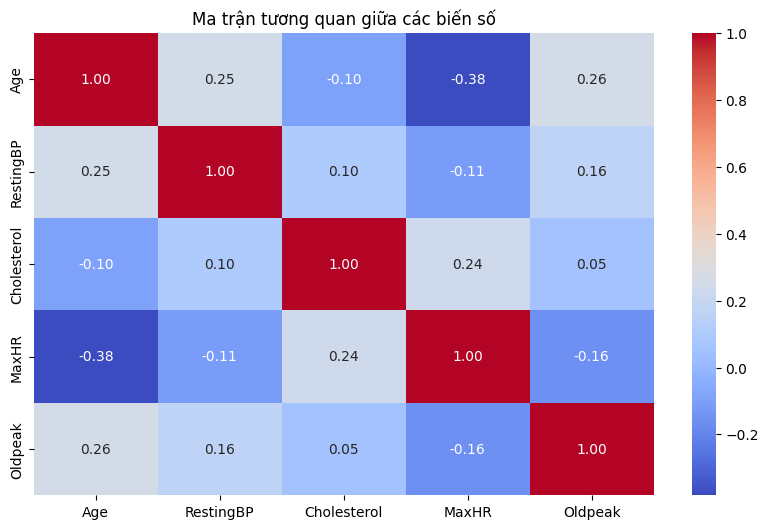

Cholesterol: giới hạn dưới = 32.62, giới hạn trên = 407.62
Số lượng outlier: 183
RestingBP: giới hạn dưới = 90.00, giới hạn trên = 170.00
Số lượng outlier: 28
Oldpeak: giới hạn dưới = -2.25, giới hạn trên = 3.75
Số lượng outlier: 16
Hoàn tất xử lý outlier.


In [3]:


import matplotlib.pyplot as plt
import seaborn as sns

df = df1.copy()  

print("Tổng quan dữ liệu Dataset 1:")
display(df.head())
print(df.describe(include='all'))



num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Phân bố của {col}")
    plt.show()


plt.figure(figsize=(4,4))
sns.countplot(x=df["HeartDisease"])
plt.title("Tỷ lệ mắc bệnh tim (0 = không bệnh, 1 = bệnh)")
plt.show()

print("Tỷ lệ mắc bệnh tim:")
print(df["HeartDisease"].value_counts(normalize=True))


plt.figure(figsize=(10, 6))
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Ma trận tương quan giữa các biến số")
plt.show()



def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(f"{column}: giới hạn dưới = {lower:.2f}, giới hạn trên = {upper:.2f}")
    print(f"Số lượng outlier: {(df[column] < lower).sum() + (df[column] > upper).sum()}")
    
    
    df[column] = df[column].clip(lower, upper)
    return df

for col in ["Cholesterol", "RestingBP", "Oldpeak"]:
    df = remove_outliers_iqr(df, col)

print("Hoàn tất xử lý outlier.")

df1 = df.copy()


## Step 2: Tiền xử lý & chia train/val/test cho Dataset 1 (Screening)

In [4]:
if 'HeartDisease' in df1.columns:
    label1 = 'HeartDisease'
elif 'heart_disease' in df1.columns:
    label1 = 'heart_disease'
else:
    label1 = df1.columns[-1]

X1 = df1.drop(columns=[label1]).copy()
y1 = df1[label1].astype(int)

numeric_cols1 = X1.select_dtypes(include=[np.number]).columns.tolist()
cat_cols1 = [c for c in X1.columns if c not in numeric_cols1]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor1 = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols1),
    ('cat', categorical_transformer, cat_cols1)
])

X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X1, y1, test_size=0.30, stratify=y1, random_state=42
)
X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp, test_size=0.50, stratify=y1_temp, random_state=42
)


## Step 3: Huấn luyện & đánh giá mô hình Screening (Dataset 1)

In [5]:
# ============================================================
# Step 3: Huấn luyện & đánh giá mô hình Screening (Dataset 1)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve, auc,
    balanced_accuracy_score
)
import joblib

# 1) Khởi tạo 2 mô hình cơ bản: Logistic Regression & Random Forest
pipe_lr1 = Pipeline([
    ("pre", preprocessor1),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

pipe_rf1 = Pipeline([
    ("pre", preprocessor1),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

# 2) Hàm đánh giá mô hình chi tiết
def evaluate_model(pipe, X, y, name="model"):
    """
    Đánh giá mô hình phân loại nhị phân với nhiều thước đo:
    - Accuracy
    - Precision
    - Recall (Sensitivity)
    - F1
    - AUC-ROC
    - AUC(PR)
    - Specificity
    - Balanced Accuracy
    """
    y_proba = pipe.predict_proba(X)[:, 1]
    y_pred = pipe.predict(X)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)  # = Sensitivity cho lớp bệnh
    f1 = f1_score(y, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y, y_proba)

    # AUC dưới đường Precision–Recall
    precisions, recalls, _ = precision_recall_curve(y, y_proba)
    auc_pr = auc(recalls, precisions)

    # Confusion matrix: TN, FP, FN, TP
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_acc = balanced_accuracy_score(y, y_pred)

    metrics = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,              # Sensitivity
        "f1": f1,
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "specificity": specificity,
        "balanced_accuracy": balanced_acc,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

    print(f"=== {name} ===")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision         : {prec:.4f}")
    print(f"Recall (Sensitivity): {rec:.4f}")
    print(f"Specificity       : {specificity:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"F1-score          : {f1:.4f}")
    print(f"AUC-ROC           : {auc_roc:.4f}")
    print(f"AUC(PR)           : {auc_pr:.4f}")
    print("-" * 50)

    return metrics


# 3) Huấn luyện 2 mô hình trên tập train
pipe_lr1.fit(X1_train, y1_train)
pipe_rf1.fit(X1_train, y1_train)

# 4) Đánh giá trên tập test để so sánh công bằng
res_lr1 = evaluate_model(pipe_lr1, X1_test, y1_test, name="LogisticRegression_DS1")
res_rf1 = evaluate_model(pipe_rf1, X1_test, y1_test, name="RandomForest_DS1")

# 5) Chọn mô hình tốt nhất theo AUC-ROC (có thể thêm tiêu chí phụ nếu cần)
if res_rf1["auc_roc"] > res_lr1["auc_roc"]:
    best_pipe_ds1 = pipe_rf1
    res_best1 = res_rf1
    best_name_ds1 = "random_forest_ds1.pkl"
    best_model_label_ds1 = "RandomForest"
else:
    best_pipe_ds1 = pipe_lr1
    res_best1 = res_lr1
    best_name_ds1 = "logreg_ds1.pkl"
    best_model_label_ds1 = "LogisticRegression"

print(f"\n>>> Mô hình tốt nhất cho Dataset 1 (theo AUC-ROC): {best_model_label_ds1}")

# 6) Lưu mô hình tốt nhất
MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path_ds1 = MODEL_DIR / best_name_ds1
joblib.dump(best_pipe_ds1, best_model_path_ds1)
print(f"Đã lưu mô hình tốt nhất DS1 vào: {best_model_path_ds1}")


=== LogisticRegression_DS1 ===
Accuracy          : 0.8768
Precision         : 0.9041
Recall (Sensitivity): 0.8684
Specificity       : 0.8871
Balanced Accuracy : 0.8778
F1-score          : 0.8859
AUC-ROC           : 0.9321
AUC(PR)           : 0.9529
--------------------------------------------------
=== RandomForest_DS1 ===
Accuracy          : 0.9130
Precision         : 0.9444
Recall (Sensitivity): 0.8947
Specificity       : 0.9355
Balanced Accuracy : 0.9151
F1-score          : 0.9189
AUC-ROC           : 0.9533
AUC(PR)           : 0.9677
--------------------------------------------------

>>> Mô hình tốt nhất cho Dataset 1 (theo AUC-ROC): RandomForest
Đã lưu mô hình tốt nhất DS1 vào: data\models\random_forest_ds1.pkl


## Step 4: Vẽ ROC, Confusion Matrix, Precision–Recall cho Dataset 1

In [6]:
# ============================================================
# Step 4: Vẽ ROC, Confusion Matrix, Precision–Recall cho DS1
# (sử dụng mô hình tốt nhất đã chọn ở Step 3)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix, precision_recall_curve, auc

def plot_roc(y_true, y_proba, title="ROC Curve"):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc_score = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], "k--", label="Random guess")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()

    # In thêm một số chỉ số trong console
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    balanced_acc = (specificity + sensitivity) / 2
    print(f"Sensitivity (Recall, True Positive Rate): {sensitivity:.4f}")
    print(f"Specificity (True Negative Rate)        : {specificity:.4f}")
    print(f"Balanced Accuracy                        : {balanced_acc:.4f}")

def plot_precision_recall(y_true, y_proba, title="Precision–Recall Curve"):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recalls, precisions)

    plt.figure(figsize=(6, 5))
    plt.plot(recalls, precisions, label=f"PR AUC = {pr_auc:.3f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(loc="upper right")
    plt.show()


# ------------------------------------------------------------
# Sử dụng kết quả từ mô hình tốt nhất (res_best1) đã chọn ở Step 3
# ------------------------------------------------------------

y1_test_proba_best = res_best1["y_proba"]
y1_test_pred_best = res_best1["y_pred"]

model_label_vn = "RandomForest" if best_pipe_ds1 is pipe_rf1 else "LogisticRegression"




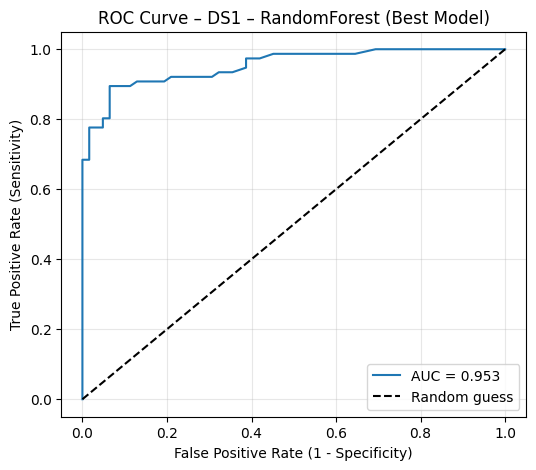

In [7]:
plot_roc(
    y1_test,
    y1_test_proba_best,
    title=f"ROC Curve – DS1 – {model_label_vn} (Best Model)"
)

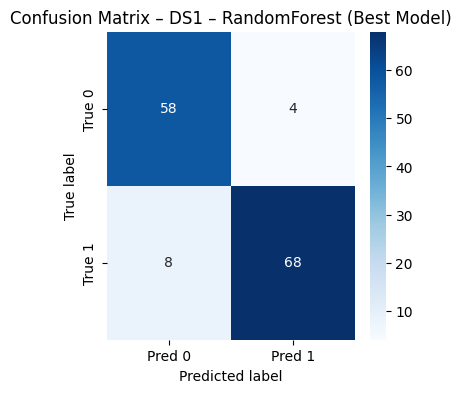

Sensitivity (Recall, True Positive Rate): 0.8947
Specificity (True Negative Rate)        : 0.9355
Balanced Accuracy                        : 0.9151


In [8]:
plot_confusion(
    y1_test,
    y1_test_pred_best,
    title=f"Confusion Matrix – DS1 – {model_label_vn} (Best Model)"
)

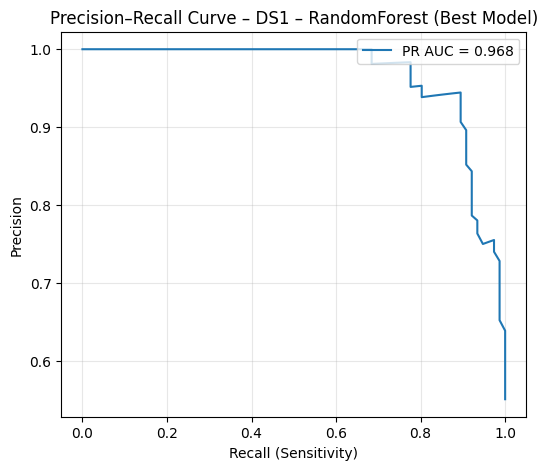

In [9]:
plot_precision_recall(
    y1_test,
    y1_test_proba_best,
    title=f"Precision–Recall Curve – DS1 – {model_label_vn} (Best Model)"
)

## Step 5: Giải thích mô hình Screening: Feature Importance & SHAP (Dataset 1)

Tổng số feature DS1:

 20

Top 10 features DS1:


Cholesterol          0.053623
Sex_M                0.047101
Sex_F                0.041667
ST_Slope_Up          0.036957
ChestPainType_ASY    0.033333
ST_Slope_Flat        0.028986
Oldpeak              0.024638
MaxHR                0.023188
ExerciseAngina_N     0.016304
ChestPainType_NAP    0.014855
dtype: float64

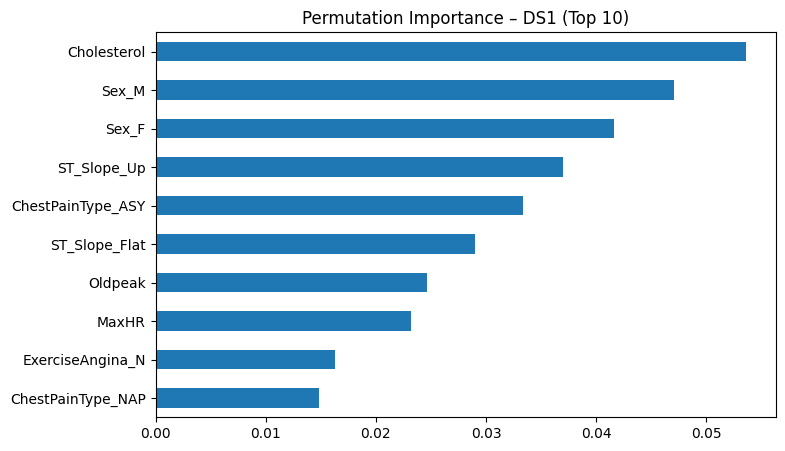

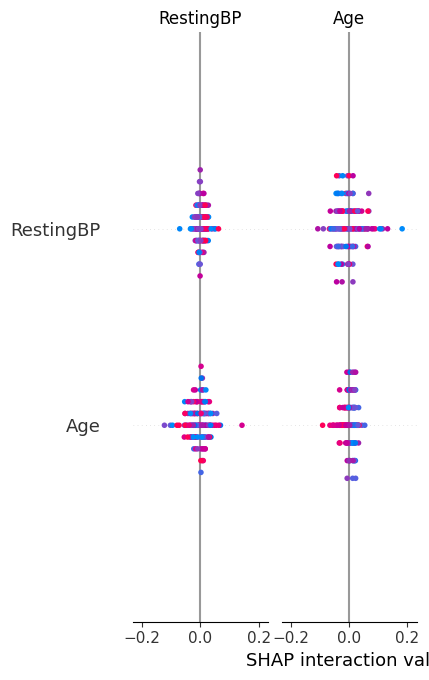

In [10]:
# ============================================================
# Step: Feature Importance + SHAP for DS1
# ============================================================

pre1 = best_pipe_ds1.named_steps['pre']
clf1 = best_pipe_ds1.named_steps['clf']

# ---- 1) Lấy tên cột sau preprocess, đúng thứ tự ----
feature_names1 = []

# numeric trước
feature_names1.extend(numeric_cols1)

# categorical (đúng thứ tự one-hot)
try:
    ohe1 = pre1.named_transformers_['cat'].named_steps['onehot']
    ohe_feature_names1 = ohe1.get_feature_names_out(cat_cols1)
    feature_names1.extend(list(ohe_feature_names1))
except:
    feature_names1.extend(cat_cols1)

print("Tổng số feature DS1:", len(feature_names1))

# ---- 2) Biến đổi X_test qua preprocessor ----
X1_test_trans = pre1.transform(X1_test)

# ---- 3) PERMUTATION IMPORTANCE ----
try:
    r1 = permutation_importance(
        clf1,
        X1_test_trans,
        y1_test,
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )
    fi1 = pd.Series(r1.importances_mean, index=feature_names1).sort_values(ascending=False)

    print("\nTop 10 features DS1:")
    display(fi1.head(10))

    plt.figure(figsize=(8,5))
    fi1.head(10).sort_values().plot(kind="barh")
    plt.title("Permutation Importance – DS1 (Top 10)")
    plt.show()
except Exception as e:
    print("Permutation importance failed DS1:", e)

# ---- 4) SHAP ----
try:
    import shap
    
    if hasattr(clf1, "feature_importances_"):   # RandomForest
        explainer1 = shap.TreeExplainer(clf1)
        shap_vals1 = explainer1.shap_values(X1_test_trans)
        
        if isinstance(shap_vals1, list):
            shap_vals1 = shap_vals1[1]  # lớp positive

        shap.summary_plot(shap_vals1, X1_test_trans, feature_names=feature_names1)

    else:   # Logistic Regression / Linear model
        explainer1 = shap.LinearExplainer(clf1, X1_test_trans)
        shap_vals1 = explainer1.shap_values(X1_test_trans)

        shap.summary_plot(shap_vals1, X1_test_trans, feature_names=feature_names1)

except Exception as e:
    print("SHAP DS1 failed:", e)


## Step 6: Đánh giá Fairness theo giới tính (Dataset 1)

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score
# -------------------------
# 1) Xác định cột giới tính
# -------------------------
sex_candidates = [c for c in df1.columns if 'sex' in c.lower()]
if not sex_candidates:
    print("Không tìm thấy cột giới tính.")
else:
    sex_col = sex_candidates[0]

    # -------------------------
    # 2) Tạo dataframe fairness
    # -------------------------
    df1_eval = pd.DataFrame(index=X1_test.index)
    df1_eval['Sex'] = df1.loc[X1_test.index, sex_col]     # lấy Sex từ df1
    df1_eval['y_true'] = y1_test.values
    df1_eval['y_pred'] = res_best1['y_pred']              # dùng mô hình TỐT NHẤT

    # -------------------------
    # 3) Tính fairness theo nhóm
    # -------------------------
    results = []
    for group, data in df1_eval.groupby('Sex'):

        tn, fp, fn, tp = confusion_matrix(
            data['y_true'], data['y_pred'], labels=[0,1]
        ).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        balanced_acc = (sensitivity + specificity) / 2

        results.append({
            "Group (Sex)": group,
            "N": len(data),
            "Accuracy": accuracy_score(data['y_true'], data['y_pred']),
            "Recall (Sensitivity)": sensitivity,
            "Specificity": specificity,
            "FPR": fpr,
            "FNR": fnr,
            "Balanced Accuracy": balanced_acc
        })

    fairness_df = pd.DataFrame(results)
    print("\n=== Fairness theo giới tính (DS1) ===")
    display(fairness_df)



=== Fairness theo giới tính (DS1) ===


,Group (Sex),N,Accuracy,Recall (Sensitivity),Specificity,FPR,FNR,Balanced Accuracy
0,F,33,0.939394,0.800000,0.964286,0.035714,0.200000,0.882143
1,M,105,0.904762,0.901408,0.911765,0.088235,0.098592,0.906587


## Step 7: Calibartion cho Dataset 1

Brier score – DS1 (càng thấp càng tốt): 0.0895


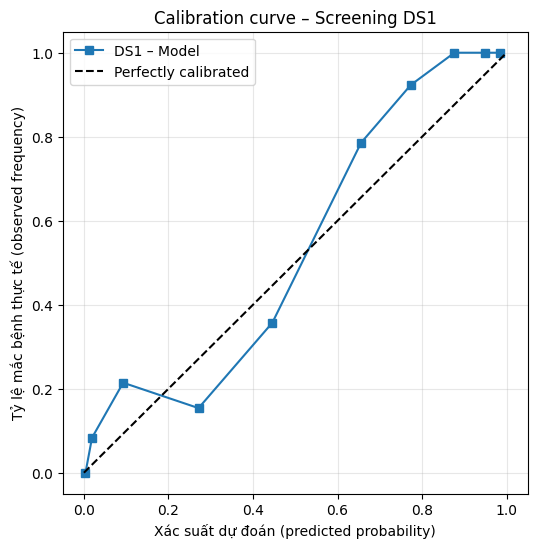

In [12]:
# ============================================================
# Step X: Calibration cho mô hình Screening DS1
# ============================================================

# 1) Lấy xác suất dự đoán từ mô hình tốt nhất DS1
y1_proba = best_pipe_ds1.predict_proba(X1_test)[:, 1]   # xác suất bị bệnh tim (label=1)

# 2) Tính Brier Score cho DS1
brier_ds1 = brier_score_loss(y1_test, y1_proba)
print(f"Brier score – DS1 (càng thấp càng tốt): {brier_ds1:.4f}")

# 3) Tính dữ liệu cho calibration curve
prob_true1, prob_pred1 = calibration_curve(
    y1_test,
    y1_proba,
    n_bins=10,
    strategy="quantile"
)

# 4) Vẽ Calibration Curve cho DS1
plt.figure(figsize=(6, 6))
plt.plot(prob_pred1, prob_true1, "s-", label="DS1 – Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Xác suất dự đoán (predicted probability)")
plt.ylabel("Tỷ lệ mắc bệnh thực tế (observed frequency)")
plt.title("Calibration curve – Screening DS1")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()


## Step: EDA và xử lí oulier cho Dataset 2

Tổng quan dữ liệu Dataset 2 (Heart Failure):


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

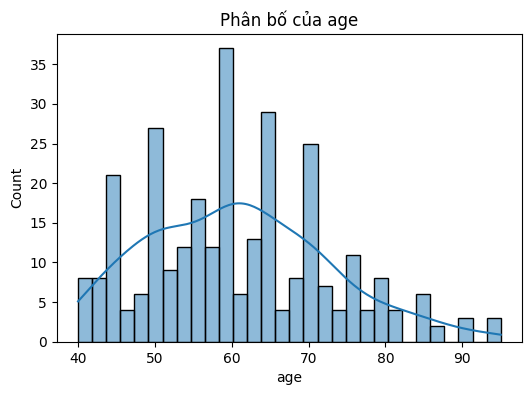

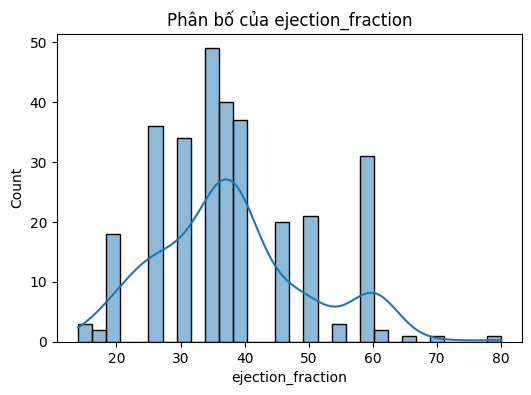

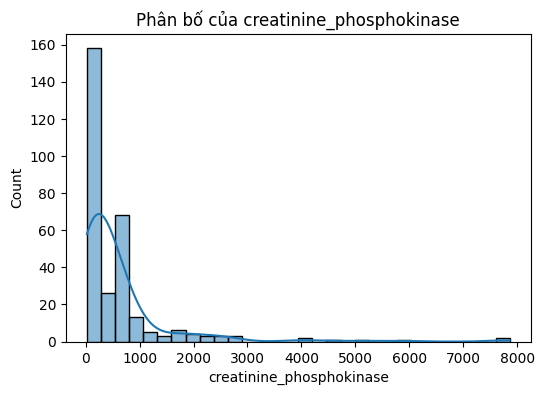

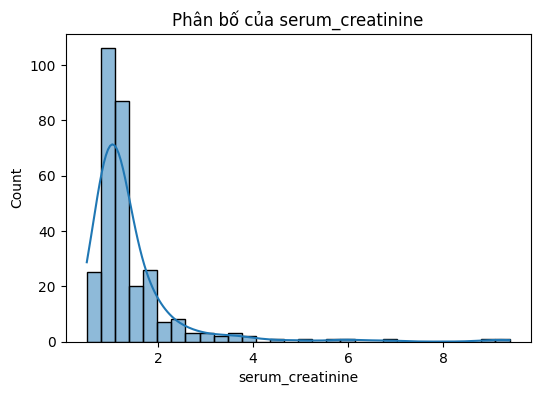

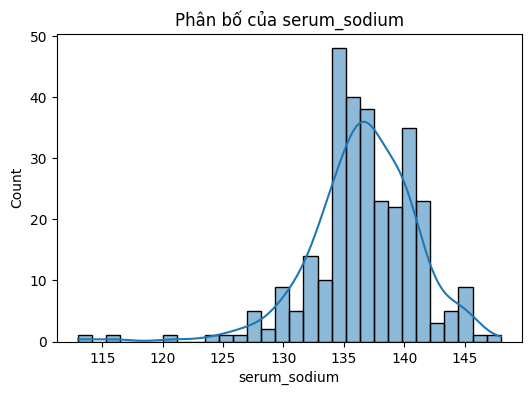

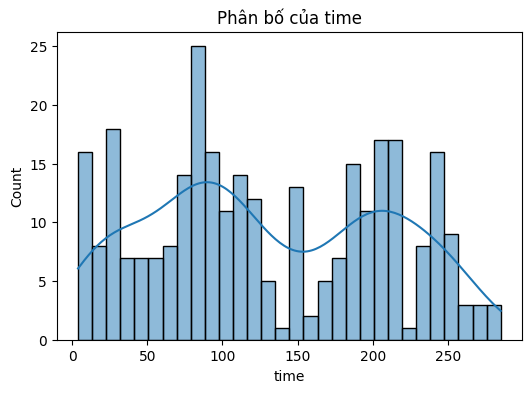

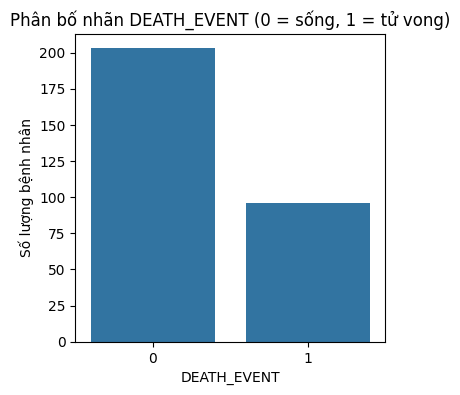

Số lượng từng lớp (DEATH_EVENT):
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Tỷ lệ phần trăm từng lớp:
DEATH_EVENT
0    67.89
1    32.11
Name: proportion, dtype: float64


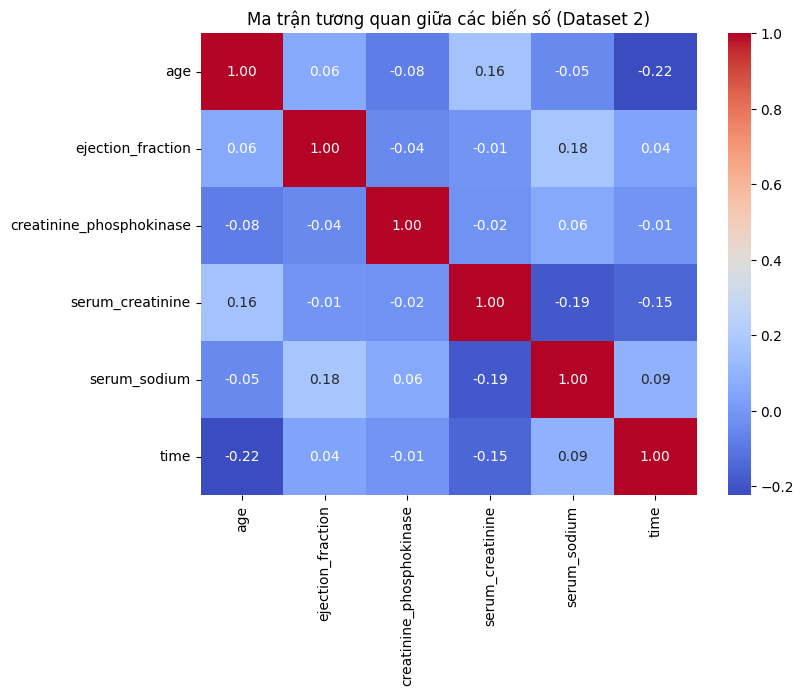


ejection_fraction: giới hạn dưới = 7.50, giới hạn trên = 67.50
Số lượng outlier (trước khi cắt): 2
Số lượng outlier (sau khi cắt): 0

creatinine_phosphokinase: giới hạn dưới = -581.75, giới hạn trên = 1280.25
Số lượng outlier (trước khi cắt): 29
Số lượng outlier (sau khi cắt): 0

serum_creatinine: giới hạn dưới = 0.15, giới hạn trên = 2.15
Số lượng outlier (trước khi cắt): 29
Số lượng outlier (sau khi cắt): 0

serum_sodium: giới hạn dưới = 125.00, giới hạn trên = 149.00
Số lượng outlier (trước khi cắt): 4
Số lượng outlier (sau khi cắt): 0

Hoàn tất xử lý outlier cho Dataset 2.


In [13]:

df_hf = df2.copy() 

print("Tổng quan dữ liệu Dataset 2 (Heart Failure):")
display(df_hf.head())
print(df_hf.describe(include='all'))

# -----------------------------
# 1) Phân bố các biến số quan trọng
# -----------------------------
num_features_hf = ["age", "ejection_fraction", "creatinine_phosphokinase",
                   "serum_creatinine", "serum_sodium", "time"]

for col in num_features_hf:
    if col in df_hf.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df_hf[col], kde=True, bins=30)
        plt.title(f"Phân bố của {col}")
        plt.show()

# -----------------------------
# 2) Phân bố nhãn DEATH_EVENT
# -----------------------------
label2 = "DEATH_EVENT" if "DEATH_EVENT" in df_hf.columns else df_hf.columns[-1]

plt.figure(figsize=(4, 4))
sns.countplot(x=df_hf[label2])
plt.title("Phân bố nhãn DEATH_EVENT (0 = sống, 1 = tử vong)")
plt.xlabel(label2)
plt.ylabel("Số lượng bệnh nhân")
plt.show()

print("Số lượng từng lớp (DEATH_EVENT):")
print(df_hf[label2].value_counts())
print("\nTỷ lệ phần trăm từng lớp:")
print(df_hf[label2].value_counts(normalize=True).mul(100).round(2))

# -----------------------------
# 3) Ma trận tương quan giữa các biến số chính
# -----------------------------
cols_for_corr = [c for c in num_features_hf if c in df_hf.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(df_hf[cols_for_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Ma trận tương quan giữa các biến số (Dataset 2)")
plt.show()

# -----------------------------
# 4) Outlier Handling bằng IQR cho một số biến
# -----------------------------
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"\n{column}: giới hạn dưới = {lower:.2f}, giới hạn trên = {upper:.2f}")
    n_outliers = ((df[column] < lower) | (df[column] > upper)).sum()
    print(f"Số lượng outlier (trước khi cắt): {n_outliers}")

    df[column] = df[column].clip(lower, upper)
    n_outliers_after = ((df[column] < lower) | (df[column] > upper)).sum()
    print(f"Số lượng outlier (sau khi cắt): {n_outliers_after}")

    return df

# Chỉ xử lý outlier cho các biến có phân bố lệch và hay bị cực trị
cols_outlier_hf = ["ejection_fraction", "creatinine_phosphokinase",
                   "serum_creatinine", "serum_sodium"]

for col in cols_outlier_hf:
    if col in df_hf.columns:
        df_hf = cap_outliers_iqr(df_hf, col)

print("\nHoàn tất xử lý outlier cho Dataset 2.")

# Cập nhật ngược lại df2 để các step sau (preprocessing, model) dùng dữ liệu đã làm sạch
df2 = df_hf.copy()


## Step: Tiền xử lý & chia train/val/test cho Dataset 2 (Prognosis)

In [14]:
label2 = 'DEATH_EVENT' if 'DEATH_EVENT' in df2.columns else df2.columns[-1]
X2 = df2.drop(columns=[label2]).copy()
y2 = df2[label2].astype(int)

numeric_cols2 = X2.select_dtypes(include=[np.number]).columns.tolist()
cat_cols2 = [c for c in X2.columns if c not in numeric_cols2]

preprocessor2 = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols2),
    ('cat', categorical_transformer, cat_cols2)
])

X2_train, X2_temp, y2_train, y2_temp = train_test_split(X2, y2, test_size=0.30, stratify=y2,  random_state=42)
X2_val, X2_test, y2_val, y2_test = train_test_split(X2_temp, y2_temp, test_size=0.50, stratify=y2_temp,  random_state=42)



## Step: Huấn luyện & đánh giá mô hình (Dataset 2)

In [15]:
# ============================================================
# Step 8: Huấn luyện & đánh giá mô hình Prognosis (Dataset 2)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
import joblib

# 1) Khởi tạo 2 mô hình: Logistic Regression & Random Forest cho DS2
pipe_lr2 = Pipeline([
    ("pre", preprocessor2),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",   # rất hữu ích nếu DEATH_EVENT lệch lớp
        random_state=42
    ))
])

pipe_rf2 = Pipeline([
    ("pre", preprocessor2),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

# 2) Huấn luyện 2 mô hình trên tập train của DS2
pipe_lr2.fit(X2_train, y2_train)
pipe_rf2.fit(X2_train, y2_train)

# 3) Đánh giá chi tiết trên tập test của DS2 bằng hàm evaluate_model đã định nghĩa trước đó
res_lr2 = evaluate_model(pipe_lr2, X2_test, y2_test, name="LogisticRegression_DS2")
res_rf2 = evaluate_model(pipe_rf2, X2_test, y2_test, name="RandomForest_DS2")

# 4) Chọn mô hình tốt nhất theo AUC-ROC (có thể cân nhắc thêm AUC-PR, Balanced Accuracy nếu muốn)
if res_rf2["auc_roc"] > res_lr2["auc_roc"]:
    best_pipe_ds2 = pipe_rf2
    res_best2 = res_rf2
    best_name_ds2 = "random_forest_ds2.pkl"
    best_model_label_ds2 = "RandomForest"
else:
    best_pipe_ds2 = pipe_lr2
    res_best2 = res_lr2
    best_name_ds2 = "logreg_ds2.pkl"
    best_model_label_ds2 = "LogisticRegression"

print(f"\n>>> Mô hình tốt nhất cho Dataset 2 (theo AUC-ROC): {best_model_label_ds2}")

# 5) Lưu mô hình tốt nhất DS2
MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path_ds2 = MODEL_DIR / best_name_ds2
joblib.dump(best_pipe_ds2, best_model_path_ds2)
print(f"Đã lưu mô hình tốt nhất DS2 vào: {best_model_path_ds2}")


=== LogisticRegression_DS2 ===
Accuracy          : 0.7556
Precision         : 0.6000
Recall (Sensitivity): 0.6429
Specificity       : 0.8065
Balanced Accuracy : 0.7247
F1-score          : 0.6207
AUC-ROC           : 0.8479
AUC(PR)           : 0.7046
--------------------------------------------------
=== RandomForest_DS2 ===
Accuracy          : 0.8222
Precision         : 0.7500
Recall (Sensitivity): 0.6429
Specificity       : 0.9032
Balanced Accuracy : 0.7730
F1-score          : 0.6923
AUC-ROC           : 0.8825
AUC(PR)           : 0.8194
--------------------------------------------------

>>> Mô hình tốt nhất cho Dataset 2 (theo AUC-ROC): RandomForest
Đã lưu mô hình tốt nhất DS2 vào: data\models\random_forest_ds2.pkl


## Step: Vẽ ROC / Confusion / Precision–Recall cho Dataset 2

In [16]:
# ============================================================
# Step 9: Vẽ ROC / Confusion / Precision–Recall cho DS2
# (dùng mô hình tốt nhất đã chọn ở Step 8)
# ============================================================


def plot_roc_ds2(y_true, y_proba, title="ROC Curve – DS2"):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc_score = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], "k--", label="Random guess")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

def plot_confusion_ds2(y_true, y_pred, title="Confusion Matrix – DS2"):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0 (Sống)", "Pred 1 (Tử vong)"],
                yticklabels=["True 0 (Sống)", "True 1 (Tử vong)"])
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()

    # In thêm các chỉ số y khoa quan trọng
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    balanced_acc = (specificity + sensitivity) / 2

    print(f"Sensitivity (Recall, True Positive Rate) – tử vong: {sensitivity:.4f}")
    print(f"Specificity (True Negative Rate) – sống        : {specificity:.4f}")
    print(f"Balanced Accuracy                              : {balanced_acc:.4f}")

def plot_precision_recall_ds2(y_true, y_proba, title="Precision–Recall – DS2"):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recalls, precisions)

    plt.figure(figsize=(6, 5))
    plt.plot(recalls, precisions, label=f"PR AUC = {pr_auc:.3f}")
    plt.xlabel("Recall (tỷ lệ bắt đúng tử vong)")
    plt.ylabel("Precision (tỷ lệ dự đoán tử vong đúng)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(loc="upper right")
    plt.show()

# ------------------------------------------------
# Dùng kết quả từ mô hình tốt nhất (res_best2)
# ------------------------------------------------
y2_test_proba_best = res_best2["y_proba"]
y2_test_pred_best = res_best2["y_pred"]

model_label_ds2_vn = "RandomForest" if best_pipe_ds2 is pipe_rf2 else "LogisticRegression"




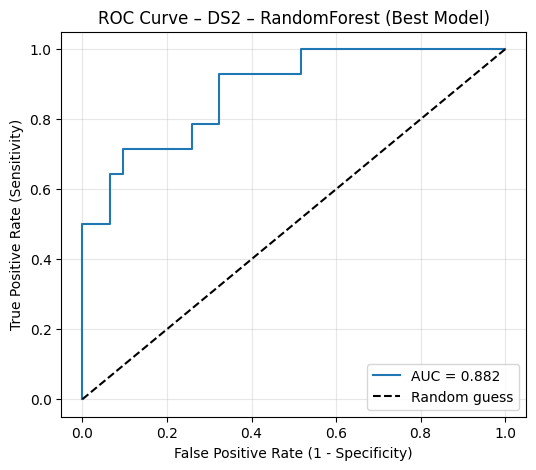

In [17]:
plot_roc_ds2(
    y2_test,
    y2_test_proba_best,
    title=f"ROC Curve – DS2 – {model_label_ds2_vn} (Best Model)"
)

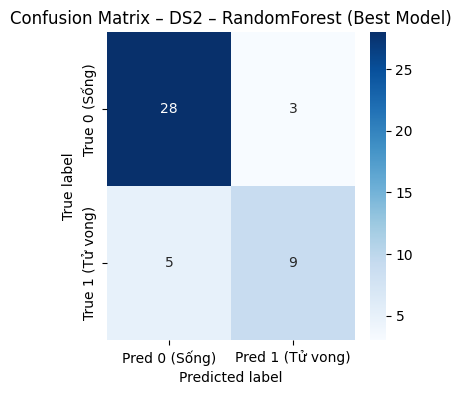

Sensitivity (Recall, True Positive Rate) – tử vong: 0.6429
Specificity (True Negative Rate) – sống        : 0.9032
Balanced Accuracy                              : 0.7730


In [18]:
plot_confusion_ds2(
    y2_test,
    y2_test_pred_best,
    title=f"Confusion Matrix – DS2 – {model_label_ds2_vn} (Best Model)"
)

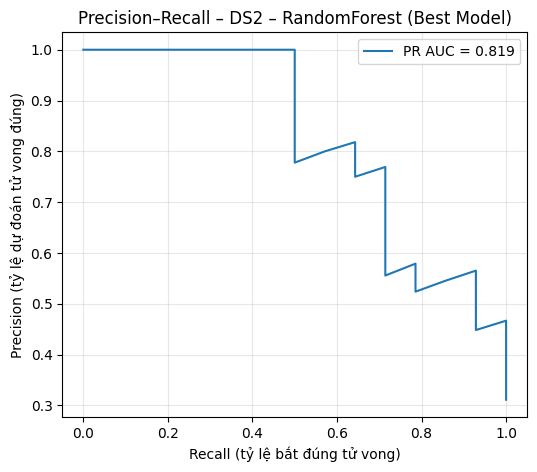

In [19]:
plot_precision_recall_ds2(
    y2_test,
    y2_test_proba_best,
    title=f"Precision–Recall – DS2 – {model_label_ds2_vn} (Best Model)"
)


## Step: Giải thích mô hình Prognosis: Feature Importance & SHAP (Dataset 2)

Tổng số feature DS2: 12

Top 10 features DS2:


time                        2.255556e-01
ejection_fraction           1.777778e-02
serum_sodium                1.555556e-02
creatinine_phosphokinase    1.444444e-02
diabetes                    1.444444e-02
sex                         6.666667e-03
smoking                     0.000000e+00
age                        -3.330669e-17
high_blood_pressure        -5.555556e-03
anaemia                    -6.666667e-03
dtype: float64

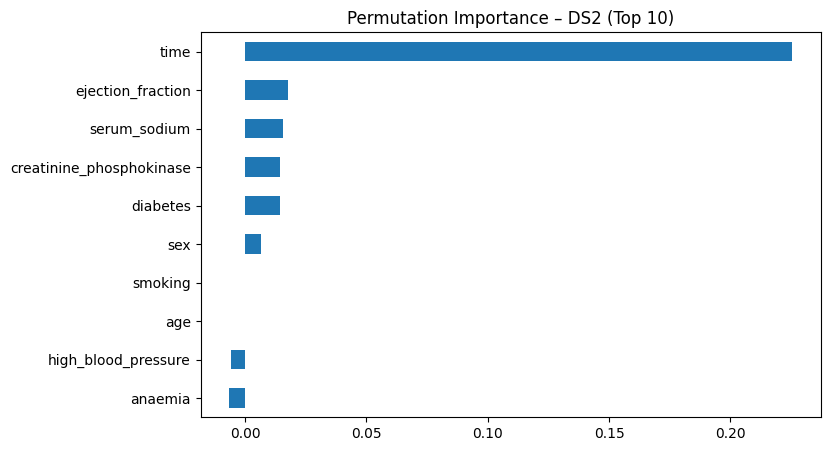

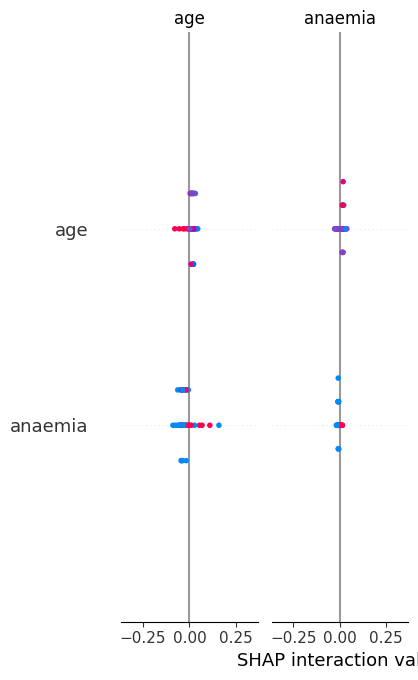

In [20]:
# ============================================================
# Step: Feature Importance + SHAP for DS2
# ============================================================

pre2 = best_pipe_ds2.named_steps['pre']
clf2 = best_pipe_ds2.named_steps['clf']

# ---- 1) Lấy tên feature đúng thứ tự ----
feature_names2 = []

feature_names2.extend(numeric_cols2)

try:
    ohe2 = pre2.named_transformers_['cat'].named_steps['onehot']
    ohe_feature_names2 = ohe2.get_feature_names_out(cat_cols2)
    feature_names2.extend(list(ohe_feature_names2))
except:
    feature_names2.extend(cat_cols2)

print("Tổng số feature DS2:", len(feature_names2))

# ---- 2) Transform test set ----
X2_test_trans = pre2.transform(X2_test)

# ---- 3) PERMUTATION IMPORTANCE ----
try:
    r2 = permutation_importance(
        clf2,
        X2_test_trans,
        y2_test,
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )
    fi2 = pd.Series(r2.importances_mean, index=feature_names2).sort_values(ascending=False)

    print("\nTop 10 features DS2:")
    display(fi2.head(10))

    plt.figure(figsize=(8,5))
    fi2.head(10).sort_values().plot(kind="barh")
    plt.title("Permutation Importance – DS2 (Top 10)")
    plt.show()
except Exception as e:
    print("Permutation importance failed DS2:", e)

# ---- 4) SHAP ----
try:
    import shap
    
    if hasattr(clf2, "feature_importances_"):   # RandomForest
        explainer2 = shap.TreeExplainer(clf2)
        shap_vals2 = explainer2.shap_values(X2_test_trans)

        if isinstance(shap_vals2, list):
            shap_vals2 = shap_vals2[1]

        shap.summary_plot(shap_vals2, X2_test_trans, feature_names=feature_names2)

    else:   # Logistic Regression
        explainer2 = shap.LinearExplainer(clf2, X2_test_trans)
        shap_vals2 = explainer2.shap_values(X2_test_trans)

        shap.summary_plot(shap_vals2, X2_test_trans, feature_names=feature_names2)

except Exception as e:
    print("SHAP DS2 failed:", e)


## Step: Calibarion cho dataset 2

Brier score – DS2 (càng thấp càng tốt): 0.1290


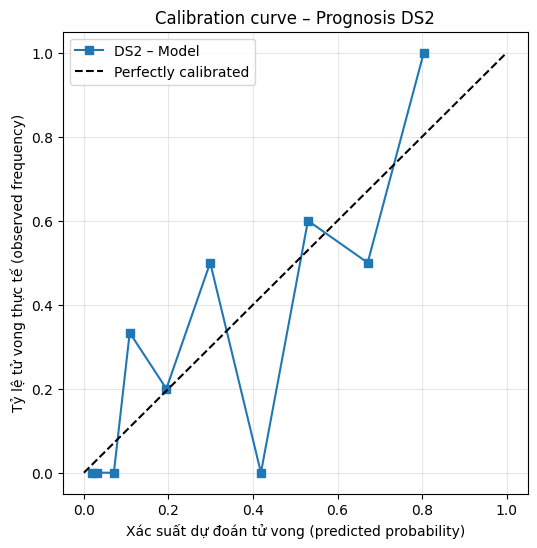

In [21]:
# ============================================================
# Step Y: Calibration cho mô hình Prognosis DS2
# ============================================================

# 1) Xác suất tử vong dự đoán bởi mô hình tốt nhất DS2
y2_proba = best_pipe_ds2.predict_proba(X2_test)[:, 1]   # xác suất DEATH_EVENT = 1

# 2) Brier Score cho DS2
brier_ds2 = brier_score_loss(y2_test, y2_proba)
print(f"Brier score – DS2 (càng thấp càng tốt): {brier_ds2:.4f}")

# 3) Calibration curve DS2
prob_true2, prob_pred2 = calibration_curve(
    y2_test,
    y2_proba,
    n_bins=10,
    strategy="quantile"
)

# 4) Vẽ Calibration Curve DS2
plt.figure(figsize=(6, 6))
plt.plot(prob_pred2, prob_true2, "s-", label="DS2 – Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Xác suất dự đoán tử vong (predicted probability)")
plt.ylabel("Tỷ lệ tử vong thực tế (observed frequency)")
plt.title("Calibration curve – Prognosis DS2")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()
